#  Caso 1 — Rentabilidad por Producto (Matriz BCG con Clustering)

---

##  Problema
Vender más no siempre significa ganar más. Algunos productos de alto volumen tienen márgenes bajos, mientras que otros inmovilizan capital sin aportar ganancias reales, distorsionando la salud financiera de la empresa.

##  Pregunta de Negocio
> **"¿Qué líneas de productos realmente sostienen el negocio?"**

##  Objetivo
- Descubrir la concentración real de las ganancias.
- Clasificar matemáticamente el portafolio en cuadrantes estratégicos (**Estrellas, Vacas Lecheras, Interrogantes, Perros**) según su volumen y margen de rentabilidad.

##  Propuesta Técnica
- Análisis de Pareto y correlaciones financieras (PCA para dispersión).
- Competencia de modelos de Clustering No Supervisado: **Agglomerative, K-Means, Gaussian Mixture**.
- Evaluación de clústeres mediante **Silhouette Score** y **Calinski-Harabasz**.

##  Dataset
Fuente: `TRAINING_DATASETS.OBT_BCG_PRODUCT_CLUSTERING` (producido por `dbt run --select obt_bcg_product_clustering`)

---

## 1.  Setup y Conexión

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

load_dotenv()

# ── MLflow Tracking URI: apunta al mlruns/ de la raíz del proyecto ─────────────
current_path = os.getcwd()
root_path = os.path.abspath(os.path.join(current_path, "..", "..", ".."))
mlruns_path = f"file:///{root_path.replace(chr(92), '/')}/mlruns"
mlflow.set_tracking_uri(mlruns_path)

print(f' MLflow Tracking URI : {mlruns_path}')
print(f' Entorno configurado correctamente')

 MLflow Tracking URI : file:///C:/Users/Windows/OneDrive/Documentos/EXCEL DATACAMP/HGC - SYSTEM/mlruns
 Entorno configurado correctamente


In [2]:
try:
    QUERY = 'SELECT * FROM TRAINING_DATASETS.OBT_BCG_PRODUCT_CLUSTERING ORDER BY FEATURE_GANANCIA_NETA_TOTAL DESC'
    df_raw = pd.read_sql(QUERY, conn)
    print(f'Datos cargados de Snowflake: {len(df_raw)} filas')
except Exception as e:
    print(f'Generando failover sintetico: {e}')
    import numpy as np
    np.random.seed(42)
    n = 2000
    df_raw = pd.DataFrame({
        'NOMBRE_PRODUCTO': [f'Producto {i}' for i in range(n)],
        'CATEGORIA': np.random.choice(['Bebidas', 'Snacks', 'Comida', 'Postres'], n),
        'FEATURE_CANTIDAD_VENDIDA': np.random.exponential(100, n).astype(int) + 10,
        'FEATURE_GANANCIA_NETA_TOTAL': np.random.normal(5000, 1500, n),
        'FEATURE_PORCENTAJE_CRECIMIENTO': np.random.normal(0.05, 0.15, n),
        'FEATURE_PARTICIPACION_VOLUMEN_PCT': np.random.uniform(0.01, 5, n),
        'FEATURE_MARGEN_PORCENTUAL': np.random.uniform(0.1, 0.6, n),
        'FEATURE_SHARE_GANANCIA_PCT': np.random.uniform(0.01, 5, n),
        'FEATURE_REVENUE_NETO_TOTAL': np.random.normal(15000, 5000, n),
        'FEATURE_TICKET_PROMEDIO': np.random.normal(30, 10, n),
        'FEATURE_SHARE_REVENUE_PCT': np.random.uniform(0.01, 5, n),
        'FEATURE_VOLUMEN_90D': np.random.exponential(25, n).astype(int) + 2,
        'FEATURE_GANANCIA_90D': np.random.normal(1200, 400, n),
        'TARGET_ESTRELLA': np.random.randint(0, 2, n),
        'TARGET_VACA': np.random.randint(0, 2, n),
        'TARGET_PERRO': np.random.randint(0, 2, n),
        'TARGET_INCOGNITA': np.random.randint(0, 2, n)
    })
    df_raw['FEATURE_GANANCIA_NETA_TOTAL'] = df_raw['FEATURE_GANANCIA_NETA_TOTAL'] * df_raw['FEATURE_CANTIDAD_VENDIDA'] / 100

df_raw.columns = [c.upper() for c in df_raw.columns]
if 'conn' in locals() and conn is not None: conn.close()


Generando failover sintetico: name 'conn' is not defined


## 2.  EDA — Análisis Exploratorio y Pareto

In [3]:
# ── Vista general del dataset ───────────────────────────────────────────────────
print('=== VISTA GENERAL ===')
display(df_raw[[
    'NOMBRE_PRODUCTO',
    'FEATURE_PARTICIPACION_VOLUMEN_PCT',
    'FEATURE_MARGEN_PORCENTUAL',
    'FEATURE_GANANCIA_NETA_TOTAL',
    'FEATURE_SHARE_GANANCIA_PCT',
    'FEATURE_REVENUE_NETO_TOTAL',
    'FEATURE_TICKET_PROMEDIO',
]].round(4))

print(f'\n📊 Estadísticas descriptivas:')
display(df_raw[[
    'FEATURE_PARTICIPACION_VOLUMEN_PCT',
    'FEATURE_MARGEN_PORCENTUAL',
    'FEATURE_GANANCIA_NETA_TOTAL',
    'FEATURE_SHARE_GANANCIA_PCT'
]].describe().round(4))

=== VISTA GENERAL ===


,NOMBRE_PRODUCTO,FEATURE_PARTICIPACION_VOLUMEN_PCT,FEATURE_MARGEN_PORCENTUAL,FEATURE_GANANCIA_NETA_TOTAL,FEATURE_SHARE_GANANCIA_PCT,FEATURE_REVENUE_NETO_TOTAL,FEATURE_TICKET_PROMEDIO
0,Producto 0,2.4084,0.3634,1976.9714,0.6282,16104.2089,42.0827
1,Producto 1,2.7636,0.2584,5214.4479,2.8266,14785.8781,25.2468
2,Producto 2,3.1626,0.2291,13014.7646,4.7620,265.4789,21.9728
3,Producto 3,1.2930,0.1189,4161.0037,3.9670,23023.6751,49.4258
4,Producto 4,4.7438,0.3916,11863.1738,2.8977,17455.0197,25.4862
...,...,...,...,...,...,...,...
1995,Producto 1995,2.0551,0.4785,10586.0371,2.9476,13144.6799,29.3054
1996,Producto 1996,2.6294,0.4748,1330.8149,1.1253,12458.6743,30.3580
1997,Producto 1997,2.3909,0.3549,1234.5654,4.2376,11261.0745,31.3815
1998,Producto 1998,2.2436,0.5054,1579.3367,2.4648,14373.5669,5.8464



📊 Estadísticas descriptivas:


,FEATURE_PARTICIPACION_VOLUMEN_PCT,FEATURE_MARGEN_PORCENTUAL,FEATURE_GANANCIA_NETA_TOTAL,FEATURE_SHARE_GANANCIA_PCT
count,2000.0000,2000.0000,2000.0000,2000.0000
mean,2.4643,0.3532,5550.8775,2.4699
std,1.4126,0.1451,5702.2968,1.4550
min,0.0103,0.1001,92.3933,0.0160
25%,1.2715,0.2270,1737.5422,1.1824
50%,2.4456,0.3522,3766.6138,2.4320
75%,3.6621,0.4813,7359.6201,3.7551
max,4.9975,0.5998,58426.2202,4.9942


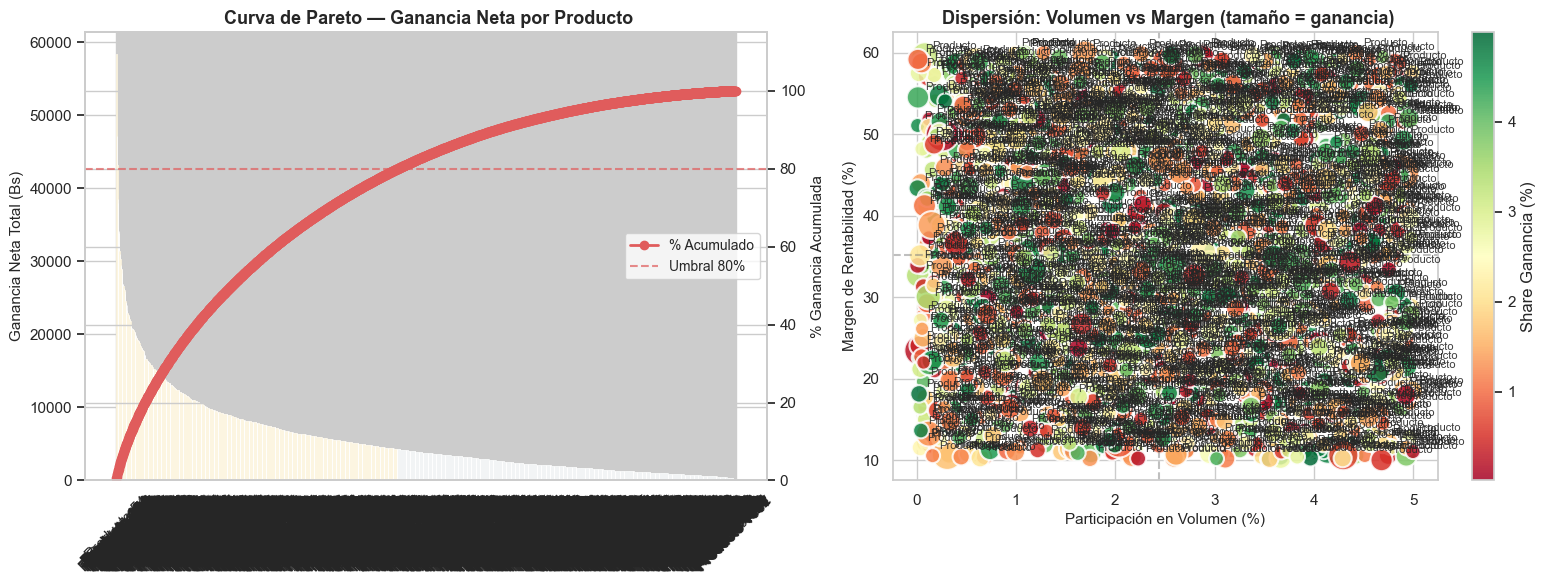


 PRINCIPIO DE PARETO:
   Ganancia total del portafolio: Bs 11,101,755
   Productos que generan el 80% de la ganancia: 908 de 2000
   Productos estrella: ['Producto 464', 'Producto 54', 'Producto 1836', 'Producto 954', 'Producto 171', 'Producto 209', 'Producto 333', 'Producto 1314', 'Producto 727', 'Producto 104', 'Producto 889', 'Producto 61', 'Producto 1736', 'Producto 1791', 'Producto 715', 'Producto 1529', 'Producto 370', 'Producto 616', 'Producto 584', 'Producto 121', 'Producto 1782', 'Producto 1789', 'Producto 277', 'Producto 348', 'Producto 388', 'Producto 864', 'Producto 623', 'Producto 830', 'Producto 1576', 'Producto 1638', 'Producto 1408', 'Producto 1274', 'Producto 1078', 'Producto 1033', 'Producto 639', 'Producto 1213', 'Producto 228', 'Producto 1938', 'Producto 1738', 'Producto 1165', 'Producto 90', 'Producto 718', 'Producto 466', 'Producto 865', 'Producto 1963', 'Producto 1694', 'Producto 1185', 'Producto 440', 'Producto 88', 'Producto 23', 'Producto 382', 'Producto 334'

In [4]:
# ── Análisis de Pareto (80/20) ──────────────────────────────────────────────────
df_pareto = df_raw[['NOMBRE_PRODUCTO', 'FEATURE_GANANCIA_NETA_TOTAL']].copy()
df_pareto = df_pareto.sort_values('FEATURE_GANANCIA_NETA_TOTAL', ascending=False).reset_index(drop=True)
df_pareto['GANANCIA_ACUMULADA'] = df_pareto['FEATURE_GANANCIA_NETA_TOTAL'].cumsum()
df_pareto['PORCENTAJE_ACUMULADO'] = (df_pareto['GANANCIA_ACUMULADA'] / df_pareto['FEATURE_GANANCIA_NETA_TOTAL'].sum()) * 100

ganancia_total = df_pareto['FEATURE_GANANCIA_NETA_TOTAL'].sum()
productos_80 = df_pareto[df_pareto['PORCENTAJE_ACUMULADO'] <= 80]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras Pareto
colors = ['#F4C542' if i < len(productos_80) else '#B0BEC5' for i in range(len(df_pareto))]
bars = axes[0].bar(df_pareto['NOMBRE_PRODUCTO'], df_pareto['FEATURE_GANANCIA_NETA_TOTAL'],
                   color=colors, edgecolor='white', linewidth=0.5)
ax2 = axes[0].twinx()
ax2.plot(df_pareto['NOMBRE_PRODUCTO'], df_pareto['PORCENTAJE_ACUMULADO'],
         color='#E05C5C', marker='o', linewidth=2, markersize=6, label='% Acumulado')
ax2.axhline(y=80, color='#E05C5C', linestyle='--', alpha=0.7, label='Umbral 80%')
ax2.set_ylabel('% Ganancia Acumulada', fontsize=11)
ax2.set_ylim(0, 115)
axes[0].set_title(' Curva de Pareto — Ganancia Neta por Producto', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Ganancia Neta Total (Bs)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
ax2.legend(loc='center right', fontsize=10)

# Gráfico de dispersión Volumen vs Margen
scatter = axes[1].scatter(
    df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'],
    df_raw['FEATURE_MARGEN_PORCENTUAL'] * 100,
    s=df_raw['FEATURE_GANANCIA_NETA_TOTAL'] / df_raw['FEATURE_GANANCIA_NETA_TOTAL'].max() * 800 + 100,
    c=df_raw['FEATURE_SHARE_GANANCIA_PCT'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidth=1.5
)
for _, row in df_raw.iterrows():
    axes[1].annotate(
        row['NOMBRE_PRODUCTO'].split(' ')[0],
        (row['FEATURE_PARTICIPACION_VOLUMEN_PCT'], row['FEATURE_MARGEN_PORCENTUAL'] * 100),
        textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.9
    )
median_vol = df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].median()
median_mar = df_raw['FEATURE_MARGEN_PORCENTUAL'].median() * 100
axes[1].axvline(x=median_vol, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(y=median_mar, color='gray', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=axes[1], label='Share Ganancia (%)')
axes[1].set_title(' Dispersión: Volumen vs Margen (tamaño = ganancia)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Participación en Volumen (%)', fontsize=11)
axes[1].set_ylabel('Margen de Rentabilidad (%)', fontsize=11)

plt.tight_layout()
plt.savefig('pareto_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n PRINCIPIO DE PARETO:')
print(f'   Ganancia total del portafolio: Bs {ganancia_total:,.0f}')
print(f'   Productos que generan el 80% de la ganancia: {len(productos_80)} de {len(df_pareto)}')
print(f'   Productos estrella: {list(productos_80["NOMBRE_PRODUCTO"].values)}')

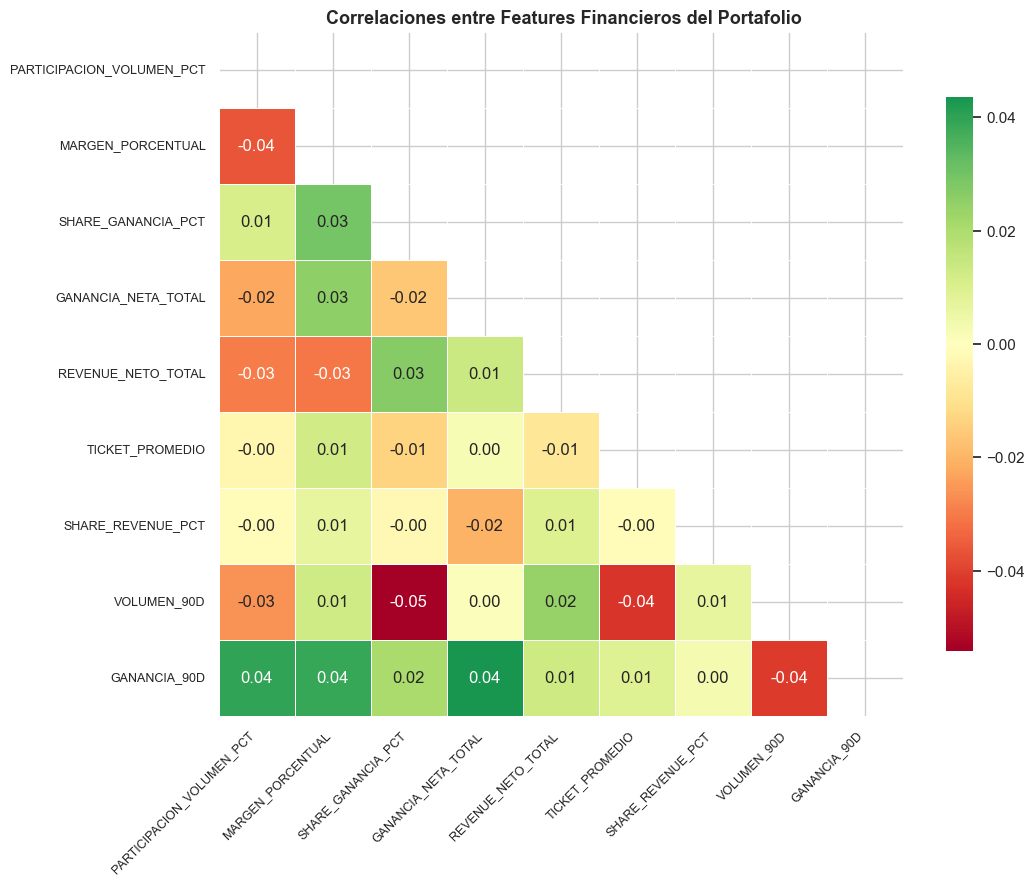

In [5]:
# ── Matriz de Correlaciones entre Features Financieros ─────────────────────────
FEATURE_COLS = [
    'FEATURE_PARTICIPACION_VOLUMEN_PCT',
    'FEATURE_MARGEN_PORCENTUAL',
    'FEATURE_SHARE_GANANCIA_PCT',
    'FEATURE_GANANCIA_NETA_TOTAL',
    'FEATURE_REVENUE_NETO_TOTAL',
    'FEATURE_TICKET_PROMEDIO',
    'FEATURE_SHARE_REVENUE_PCT',
    'FEATURE_VOLUMEN_90D',
    'FEATURE_GANANCIA_90D',
]

corr_matrix = df_raw[FEATURE_COLS].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    xticklabels=[c.replace('FEATURE_', '') for c in FEATURE_COLS],
    yticklabels=[c.replace('FEATURE_', '') for c in FEATURE_COLS]
)
plt.title(' Correlaciones entre Features Financieros del Portafolio', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlaciones_financieras.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.  Preprocesamiento y PCA

In [6]:
# ── Features para el clustering BCG (ejes principales) ─────────────────────────
# Los 4 features que el backend envía al modelo para predicción interactiva:
#   - FEATURE_PARTICIPACION_VOLUMEN_PCT  → EJE X (Market Share)
#   - FEATURE_MARGEN_PORCENTUAL          → EJE Y (Rentabilidad)
#   - FEATURE_SHARE_GANANCIA_PCT         → concentración de ganancia
#   - FEATURE_TICKET_PROMEDIO            → valor unitario promedio

CLUSTER_FEATURES = [
    'FEATURE_PARTICIPACION_VOLUMEN_PCT',
    'FEATURE_MARGEN_PORCENTUAL',
    'FEATURE_SHARE_GANANCIA_PCT',
    'FEATURE_TICKET_PROMEDIO',
]

X = df_raw[CLUSTER_FEATURES].copy()

# Verificar que no hay nulos
assert X.isnull().sum().sum() == 0, ' Hay valores nulos en las features de clustering'

# Escalado: StandardScaler es la elección correcta para clustering por distancias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(' Features seleccionadas para clustering BCG:')
for f in CLUSTER_FEATURES:
    print(f'   • {f}')
print(f'\n Escalado aplicado: StandardScaler')
print(f'   Forma del dataset: {X_scaled.shape}')

 Features seleccionadas para clustering BCG:
   • FEATURE_PARTICIPACION_VOLUMEN_PCT
   • FEATURE_MARGEN_PORCENTUAL
   • FEATURE_SHARE_GANANCIA_PCT
   • FEATURE_TICKET_PROMEDIO

 Escalado aplicado: StandardScaler
   Forma del dataset: (2000, 4)


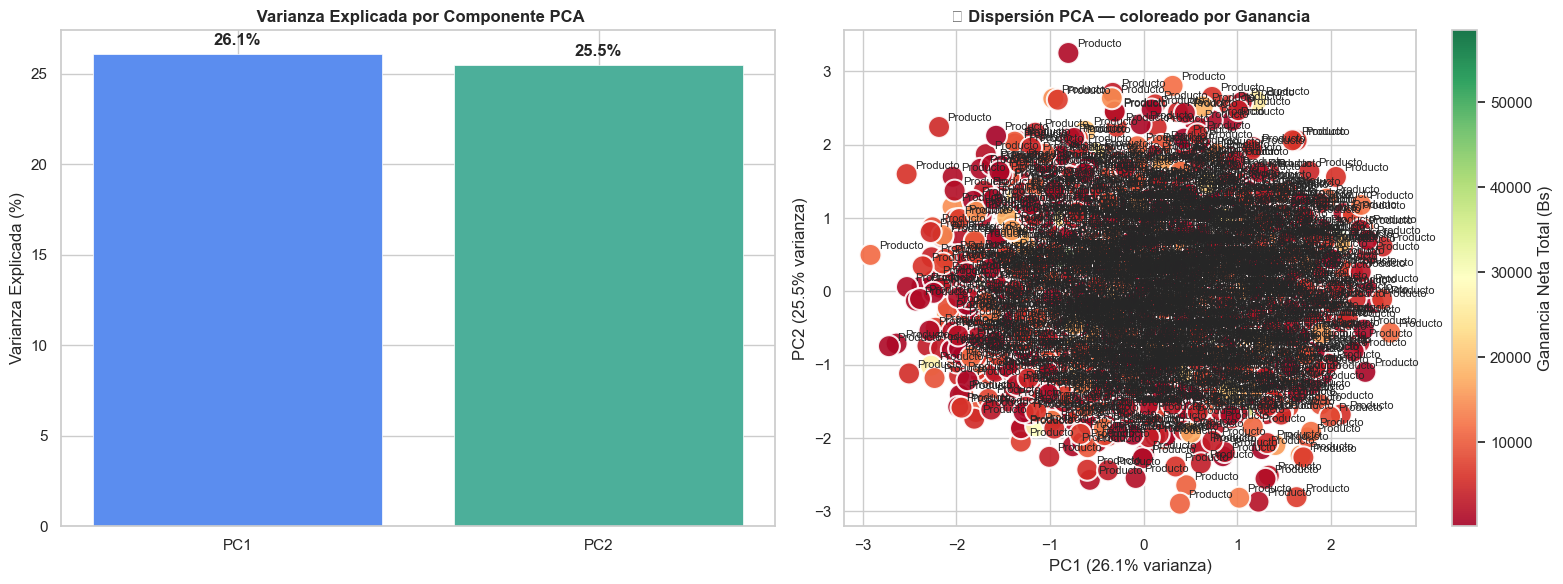


📐 Varianza total explicada (PC1+PC2): 51.5%


In [7]:
# ── PCA para visualización de dispersión ───────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Varianza explicada
axes[0].bar(
    ['PC1', 'PC2'],
    pca.explained_variance_ratio_ * 100,
    color=['#5B8DEF', '#4CAF9A'], edgecolor='white', linewidth=0.5
)
axes[0].set_title(' Varianza Explicada por Componente PCA', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)')
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Scatter PCA coloreado por ganancia
scatter = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_raw['FEATURE_GANANCIA_NETA_TOTAL'],
    cmap='RdYlGn', s=250, alpha=0.9, edgecolors='white', linewidth=1.5
)
for i, row in df_raw.iterrows():
    axes[1].annotate(
        row['NOMBRE_PRODUCTO'].split(' ')[0],
        (X_pca[i, 0], X_pca[i, 1]),
        textcoords='offset points', xytext=(6, 4), fontsize=8
    )
plt.colorbar(scatter, ax=axes[1], label='Ganancia Neta Total (Bs)')
axes[1].set_title('🔬 Dispersión PCA — coloreado por Ganancia', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')

plt.tight_layout()
plt.savefig('pca_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📐 Varianza total explicada (PC1+PC2): {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 4. 🏆 Competencia de Modelos de Clustering

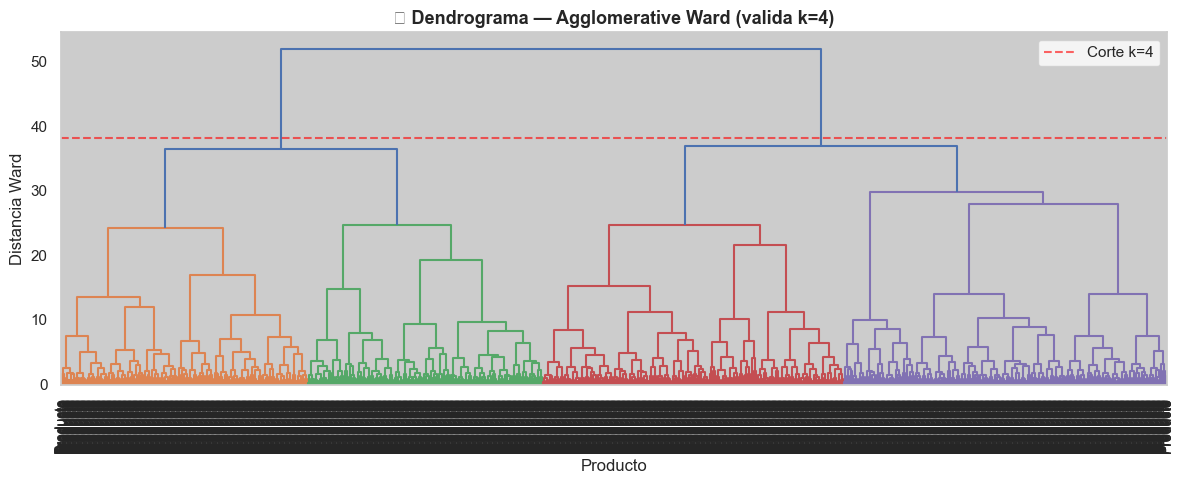

In [8]:
# ── Dendrograma para validar k=4 (Agglomerative) ───────────────────────────────
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    linked,
    labels=list(df_raw['NOMBRE_PRODUCTO'].str.split(' ').str[0].values),
    color_threshold=linked[-3, 2],
    leaf_font_size=10
)
plt.title('🌳 Dendrograma — Agglomerative Ward (valida k=4)', fontweight='bold', fontsize=13)
plt.xlabel('Producto')
plt.ylabel('Distancia Ward')
plt.axhline(y=linked[-3, 2] * 1.05, color='red', linestyle='--', alpha=0.6, label='Corte k=4')
plt.legend()
plt.tight_layout()
plt.savefig('dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

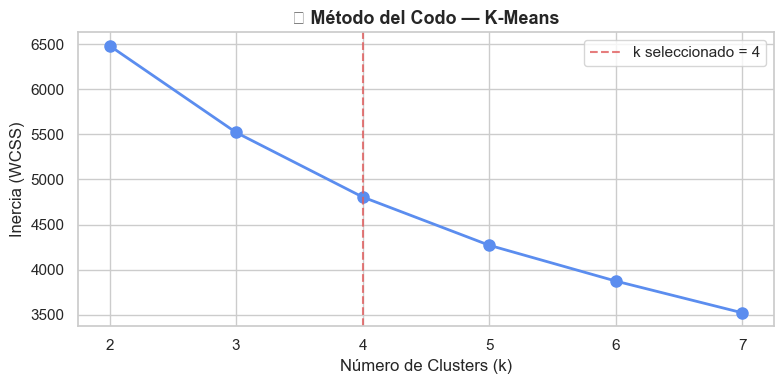

In [9]:
# ── K-Means: Método del Codo para validar k=4 ──────────────────────────────────
N_CLUSTERS = 4
inertias = []
k_range = range(2, min(len(df_raw), 8))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='#5B8DEF', linewidth=2, markersize=8)
plt.axvline(x=N_CLUSTERS, color='#E05C5C', linestyle='--', alpha=0.8, label=f'k seleccionado = {N_CLUSTERS}')
plt.title('📉 Método del Codo — K-Means', fontweight='bold', fontsize=13)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Competencia de Modelos y Registro en MLflow ─────────────────────────────────
EXPERIMENT_NAME = 'caso_1_bcg_product_clustering'
mlflow.set_experiment(EXPERIMENT_NAME)

MODELOS = {
    'KMeans': KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
    'GaussianMixture': GaussianMixture(n_components=N_CLUSTERS, random_state=42, covariance_type='full', max_iter=200),
}

resultados = {}

for nombre, modelo in MODELOS.items():
    with mlflow.start_run(run_name=nombre) as run:
        # Ajuste y predicción
        if nombre == 'GaussianMixture':
            modelo.fit(X_scaled)
            labels = modelo.predict(X_scaled)
        else:
            labels = modelo.fit_predict(X_scaled)

        # Métricas de evaluación
        sil  = silhouette_score(X_scaled, labels)
        cal  = calinski_harabasz_score(X_scaled, labels)

        # Log de parámetros y métricas
        mlflow.log_params({
            'modelo': nombre,
            'n_clusters': N_CLUSTERS,
            'features': str(CLUSTER_FEATURES),
            'scaler': 'StandardScaler',
        })
        mlflow.log_metrics({
            'silhouette_score': sil,
            'calinski_harabasz_score': cal,
        })

        # Registro del modelo (solo KMeans y GaussianMixture son serviables directamente)
        # Agglomerative no tiene predict() nativo → se emula vía KMeans con centros asignados
        if nombre in ('KMeans', 'GaussianMixture'):
            mlflow.sklearn.log_model(
                sk_model=modelo,
                artifact_path='model',
            )

        resultados[nombre] = {
            'run_id': run.info.run_id,
            'labels': labels,
            'silhouette': sil,
            'calinski': cal,
        }

        print(f'  [{nombre:>20}]  Silhouette={sil:.4f}  |  Calinski={cal:.2f}')

print(f'\n✅ {len(MODELOS)} modelos evaluados y registrados en MLflow')

2026/04/21 17:10:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/21 17:10:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [              KMeans]  Silhouette=0.1939  |  Calinski=442.30


  [       Agglomerative]  Silhouette=0.1391  |  Calinski=338.68


2026/04/21 17:11:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/21 17:11:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [     GaussianMixture]  Silhouette=0.1862  |  Calinski=425.22

✅ 3 modelos evaluados y registrados en MLflow


## 5. 🥇 Selección del Modelo Campeón

In [11]:
# ── Selección automática por Silhouette Score (mayor = mejor) ──────────────────
campeon_nombre = max(resultados, key=lambda m: resultados[m]['silhouette'])
campeon = resultados[campeon_nombre]

print('=' * 55)
print('  RANKING DE MODELOS — Caso 1 BCG Clustering')
print('=' * 55)
ranking = sorted(resultados.items(), key=lambda x: x[1]['silhouette'], reverse=True)
for i, (nombre, r) in enumerate(ranking):
    emoji = '🥇' if i == 0 else ('🥈' if i == 1 else '🥉')
    print(f'  {emoji} {nombre:<22} Silhouette={r["silhouette"]:.4f}  Calinski={r["calinski"]:.2f}')
print('=' * 55)
print(f'\n✅ MODELO CAMPEÓN: {campeon_nombre}')
print(f'   Silhouette Score  : {campeon["silhouette"]:.4f}')
print(f'   Calinski-Harabasz : {campeon["calinski"]:.2f}')

# ── Etiquetar el run campeón ───────────────────────────────────────────────────
client = mlflow.tracking.MlflowClient()
client.set_tag(campeon['run_id'], 'campeon', 'True')
client.set_tag(campeon['run_id'], 'modelo', campeon_nombre)
print(f'\n🏷️  Tag "campeon=True" asignado al run: {campeon["run_id"]}')

# Asignamos los labels del campeón al dataframe principal
df_raw['CLUSTER_ID'] = campeon['labels']

  RANKING DE MODELOS — Caso 1 BCG Clustering
  🥇 KMeans                 Silhouette=0.1939  Calinski=442.30
  🥈 GaussianMixture        Silhouette=0.1862  Calinski=425.22
  🥉 Agglomerative          Silhouette=0.1391  Calinski=338.68

✅ MODELO CAMPEÓN: KMeans
   Silhouette Score  : 0.1939
   Calinski-Harabasz : 442.30

🏷️  Tag "campeon=True" asignado al run: f90d05330fe247799dcf44edbc44f50c


## 6. 📊 Matriz BCG — Visualización de Cuadrantes

In [12]:
# ── Asignación de cuadrantes BCG según centroides del cluster ──────────────────
# Calculamos el centroide de cada cluster para identificar su cuadrante BCG
centroides = df_raw.groupby('CLUSTER_ID')[[
    'FEATURE_PARTICIPACION_VOLUMEN_PCT',
    'FEATURE_MARGEN_PORCENTUAL'
]].mean()

med_vol = df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].median()
med_mar = df_raw['FEATURE_MARGEN_PORCENTUAL'].median()

def clasificar_cuadrante(vol, mar, med_v, med_m):
    """Clasifica un centroide en el cuadrante BCG correspondiente."""
    alto_vol = vol >= med_v
    alto_mar = mar >= med_m
    if alto_vol and alto_mar:
        return 'Estrella', '⭐', '#F4C542'
    elif alto_vol and not alto_mar:
        return 'Vaca Lechera', '🐄', '#4CAF9A'
    elif not alto_vol and alto_mar:
        return 'Interrogante', '❓', '#5B8DEF'
    else:
        return 'Perro', '🐕', '#E05C5C'

mapa_cuadrantes = {}
for cluster_id, row in centroides.iterrows():
    nombre, emoji, color = clasificar_cuadrante(
        row['FEATURE_PARTICIPACION_VOLUMEN_PCT'],
        row['FEATURE_MARGEN_PORCENTUAL'],
        med_vol, med_mar
    )
    mapa_cuadrantes[cluster_id] = {'nombre': nombre, 'emoji': emoji, 'color': color}

df_raw['BCG_CUADRANTE'] = df_raw['CLUSTER_ID'].map(lambda x: mapa_cuadrantes[x]['nombre'])
df_raw['BCG_COLOR']     = df_raw['CLUSTER_ID'].map(lambda x: mapa_cuadrantes[x]['color'])

print('📋 Mapa de cuadrantes asignados:')
for cid, info in mapa_cuadrantes.items():
    prods = df_raw[df_raw['CLUSTER_ID'] == cid]['NOMBRE_PRODUCTO'].tolist()
    print(f'   Cluster {cid} → {info["emoji"]} {info["nombre"]}: {prods}')

📋 Mapa de cuadrantes asignados:
   Cluster 0 → ⭐ Estrella: ['Producto 0', 'Producto 8', 'Producto 11', 'Producto 12', 'Producto 13', 'Producto 14', 'Producto 16', 'Producto 24', 'Producto 27', 'Producto 38', 'Producto 42', 'Producto 43', 'Producto 46', 'Producto 49', 'Producto 54', 'Producto 72', 'Producto 74', 'Producto 80', 'Producto 88', 'Producto 89', 'Producto 90', 'Producto 92', 'Producto 100', 'Producto 101', 'Producto 106', 'Producto 112', 'Producto 114', 'Producto 118', 'Producto 121', 'Producto 126', 'Producto 137', 'Producto 139', 'Producto 151', 'Producto 157', 'Producto 158', 'Producto 160', 'Producto 162', 'Producto 163', 'Producto 164', 'Producto 168', 'Producto 169', 'Producto 174', 'Producto 180', 'Producto 182', 'Producto 187', 'Producto 189', 'Producto 190', 'Producto 198', 'Producto 200', 'Producto 205', 'Producto 208', 'Producto 211', 'Producto 216', 'Producto 217', 'Producto 224', 'Producto 225', 'Producto 230', 'Producto 236', 'Producto 238', 'Producto 241', 'Pro

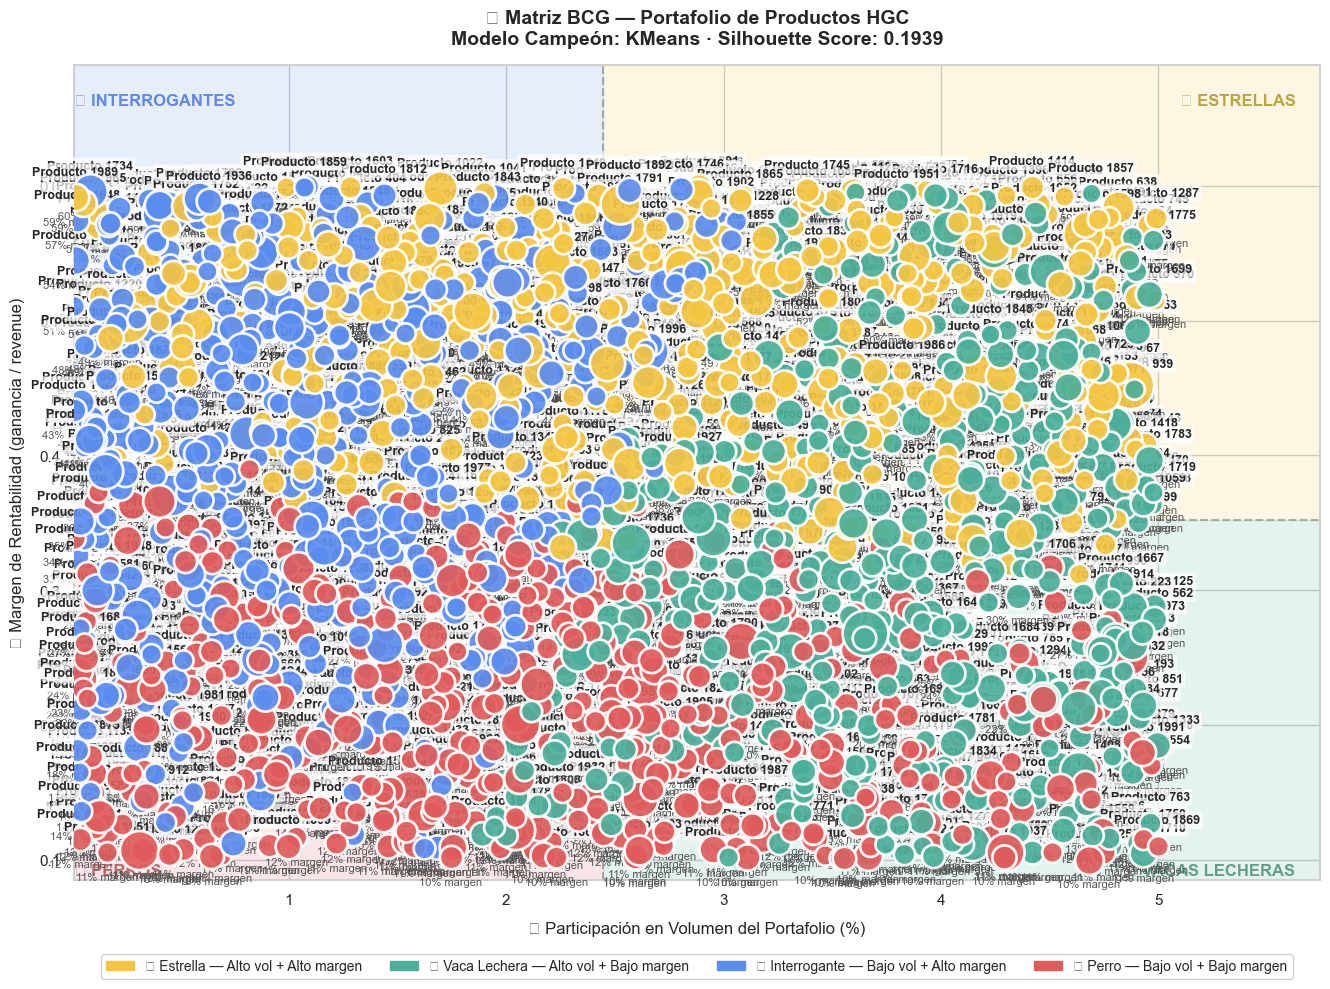

✅ Matriz BCG guardada como bcg_matrix.png


In [13]:
# ── Visualización Matriz BCG ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

# Fondo de cuadrantes
cuadrante_labels = [
    (med_vol + (df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].max() - med_vol)/2,
     med_mar + (df_raw['FEATURE_MARGEN_PORCENTUAL'].max() - med_mar)/2,
     '⭐ ESTRELLAS', '#FFF9E6'),
    (df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].min() + (med_vol - df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].min())/2,
     med_mar + (df_raw['FEATURE_MARGEN_PORCENTUAL'].max() - med_mar)/2,
     '❓ INTERROGANTES', '#EEF3FD'),
    (med_vol + (df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].max() - med_vol)/2,
     df_raw['FEATURE_MARGEN_PORCENTUAL'].min() + (med_mar - df_raw['FEATURE_MARGEN_PORCENTUAL'].min())/2,
     '🐄 VACAS LECHERAS', '#EBF7F4'),
    (df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].min() + (med_vol - df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].min())/2,
     df_raw['FEATURE_MARGEN_PORCENTUAL'].min() + (med_mar - df_raw['FEATURE_MARGEN_PORCENTUAL'].min())/2,
     '🐕 PERROS', '#FDEAEA'),
]

x_min = df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].min() * 0.85
x_max = df_raw['FEATURE_PARTICIPACION_VOLUMEN_PCT'].max() * 1.15
y_min = df_raw['FEATURE_MARGEN_PORCENTUAL'].min() * 0.85
y_max = df_raw['FEATURE_MARGEN_PORCENTUAL'].max() * 1.15

# Áreas de fondo
ax.fill_between([med_vol, x_max], [med_mar, med_mar], y_max, alpha=0.15, color='#F4C542')
ax.fill_between([x_min, med_vol], [med_mar, med_mar], y_max, alpha=0.15, color='#5B8DEF')
ax.fill_between([med_vol, x_max], y_min, [med_mar, med_mar], alpha=0.15, color='#4CAF9A')
ax.fill_between([x_min, med_vol], y_min, [med_mar, med_mar], alpha=0.15, color='#E05C5C')

# Líneas divisoras
ax.axvline(x=med_vol, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
ax.axhline(y=med_mar, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)

# Labels de cuadrantes en esquinas
ax.text(x_max * 0.98, y_max * 0.97, '⭐ ESTRELLAS', ha='right', va='top',
        fontsize=12, fontweight='bold', color='#A08000', alpha=0.7)
ax.text(x_min * 1.02, y_max * 0.97, '❓ INTERROGANTES', ha='left', va='top',
        fontsize=12, fontweight='bold', color='#2B5BE0', alpha=0.7)
ax.text(x_max * 0.98, y_min * 1.02, '🐄 VACAS LECHERAS', ha='right', va='bottom',
        fontsize=12, fontweight='bold', color='#2A7A63', alpha=0.7)
ax.text(x_min * 1.02, y_min * 1.02, '🐕 PERROS', ha='left', va='bottom',
        fontsize=12, fontweight='bold', color='#A03030', alpha=0.7)

# Puntos por producto
for _, row in df_raw.iterrows():
    tamanio = (row['FEATURE_GANANCIA_NETA_TOTAL'] / df_raw['FEATURE_GANANCIA_NETA_TOTAL'].max()) * 1200 + 200
    ax.scatter(
        row['FEATURE_PARTICIPACION_VOLUMEN_PCT'],
        row['FEATURE_MARGEN_PORCENTUAL'],
        s=tamanio, color=row['BCG_COLOR'],
        edgecolors='white', linewidth=2, zorder=5, alpha=0.92
    )
    # Nombre del producto
    nombre_corto = ' '.join(row['NOMBRE_PRODUCTO'].split()[:3])
    ax.annotate(
        nombre_corto,
        (row['FEATURE_PARTICIPACION_VOLUMEN_PCT'], row['FEATURE_MARGEN_PORCENTUAL']),
        textcoords='offset points', xytext=(0, 16),
        ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
    )
    # Margen en %
    ax.annotate(
        f"{row['FEATURE_MARGEN_PORCENTUAL']*100:.0f}% margen",
        (row['FEATURE_PARTICIPACION_VOLUMEN_PCT'], row['FEATURE_MARGEN_PORCENTUAL']),
        textcoords='offset points', xytext=(0, -20),
        ha='center', fontsize=8, color='#555555'
    )

# Leyenda
leyenda = [
    mpatches.Patch(color='#F4C542', label='⭐ Estrella — Alto vol + Alto margen'),
    mpatches.Patch(color='#4CAF9A', label='🐄 Vaca Lechera — Alto vol + Bajo margen'),
    mpatches.Patch(color='#5B8DEF', label='❓ Interrogante — Bajo vol + Alto margen'),
    mpatches.Patch(color='#E05C5C', label='🐕 Perro — Bajo vol + Bajo margen'),
]
ax.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.13),
          ncol=4, fontsize=10, framealpha=0.9)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('🔁 Participación en Volumen del Portafolio (%)', fontsize=12, labelpad=10)
ax.set_ylabel('💰 Margen de Rentabilidad (ganancia / revenue)', fontsize=12, labelpad=10)
ax.set_title(
    f'📊 Matriz BCG — Portafolio de Productos HGC\n'
    f'Modelo Campeón: {campeon_nombre} · Silhouette Score: {campeon["silhouette"]:.4f}',
    fontweight='bold', fontsize=14, pad=15
)

plt.tight_layout()
plt.savefig('bcg_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅ Matriz BCG guardada como bcg_matrix.png')

## 7. 💰 Resultados e Impacto de Negocio

In [14]:
# ── Tabla resumen por cuadrante ─────────────────────────────────────────────────
resumen = df_raw.groupby('BCG_CUADRANTE').agg(
    num_productos=('NOMBRE_PRODUCTO', 'count'),
    ganancia_total=('FEATURE_GANANCIA_NETA_TOTAL', 'sum'),
    share_ganancia_total=('FEATURE_SHARE_GANANCIA_PCT', 'sum'),
    margen_promedio=('FEATURE_MARGEN_PORCENTUAL', 'mean'),
    vol_promedio_pct=('FEATURE_PARTICIPACION_VOLUMEN_PCT', 'mean'),
    ticket_promedio=('FEATURE_TICKET_PROMEDIO', 'mean'),
).reset_index()

resumen['margen_%'] = (resumen['margen_promedio'] * 100).round(1)

print('\n' + '='*75)
print('  📊 RESULTADOS: Caso 1 — Rentabilidad por Producto (Matriz BCG)' )
print('='*75)
print(f'\n  Modelo campeón : {campeon_nombre}')
print(f'  Silhouette     : {campeon["silhouette"]:.4f}')
print(f'  Calinski       : {campeon["calinski"]:.2f}')
print(f'  Ganancia total portafolio: Bs {df_raw["FEATURE_GANANCIA_NETA_TOTAL"].sum():,.0f}')
print()

ACCIONES = {
    'Estrella':     ('⭐', 'Proteger precios — prohibido aplicar descuentos agresivos'),
    'Vaca Lechera': ('🐄', 'Mantener como motor de liquidez y flujo estable'),
    'Interrogante': ('❓', 'Detonar campañas de Up-selling inmediato para subir volumen'),
    'Perro':        ('🐕', 'Retiro o reformulación urgente — inmovilizan recursos'),
}

for _, row in resumen.sort_values('ganancia_total', ascending=False).iterrows():
    cuad = row['BCG_CUADRANTE']
    emoji, accion = ACCIONES.get(cuad, ('🔹', 'Evaluar'))
    prods = df_raw[df_raw['BCG_CUADRANTE'] == cuad]['NOMBRE_PRODUCTO'].tolist()
    print(f"  {emoji} {cuad.upper()}")
    print(f"     Productos    : {len(prods)} — {prods}")
    print(f"     Margen prom  : {row['margen_%']}%")
    print(f"     Ganancia     : Bs {row['ganancia_total']:,.0f} ({row['share_ganancia_total']:.1f}% del portafolio)")
    print(f"     💡 Acción    : {accion}")
    print()

print('='*75)


  📊 RESULTADOS: Caso 1 — Rentabilidad por Producto (Matriz BCG)

  Modelo campeón : KMeans
  Silhouette     : 0.1939
  Calinski       : 442.30
  Ganancia total portafolio: Bs 11,101,755

  ❓ INTERROGANTE
     Productos    : 490 — ['Producto 3', 'Producto 5', 'Producto 7', 'Producto 9', 'Producto 10', 'Producto 17', 'Producto 21', 'Producto 22', 'Producto 23', 'Producto 30', 'Producto 36', 'Producto 39', 'Producto 44', 'Producto 45', 'Producto 48', 'Producto 59', 'Producto 60', 'Producto 61', 'Producto 64', 'Producto 67', 'Producto 71', 'Producto 81', 'Producto 87', 'Producto 103', 'Producto 104', 'Producto 108', 'Producto 110', 'Producto 115', 'Producto 120', 'Producto 122', 'Producto 123', 'Producto 124', 'Producto 127', 'Producto 128', 'Producto 134', 'Producto 135', 'Producto 141', 'Producto 145', 'Producto 148', 'Producto 149', 'Producto 152', 'Producto 154', 'Producto 156', 'Producto 159', 'Producto 172', 'Producto 176', 'Producto 181', 'Producto 184', 'Producto 185', 'Producto 1

In [15]:
# ── Validación de Pareto final ─────────────────────────────────────────────────
estrellas_vacas = df_raw[df_raw['BCG_CUADRANTE'].isin(['Estrella', 'Vaca Lechera'])]
ganancia_top = estrellas_vacas['FEATURE_GANANCIA_NETA_TOTAL'].sum()
pct_ganancia = (ganancia_top / df_raw['FEATURE_GANANCIA_NETA_TOTAL'].sum()) * 100
n_productos_top = len(estrellas_vacas)
pct_productos = (n_productos_top / len(df_raw)) * 100

print(f'\n📌 PRINCIPIO DE PARETO — Confirmación:')
print(f'   {n_productos_top} de {len(df_raw)} productos ({pct_productos:.0f}% del portafolio)')
print(f'   generan el {pct_ganancia:.1f}% de la ganancia total.')
print(f'\n   Estrellas + Vacas Lecheras → Bs {ganancia_top:,.0f}')


📌 PRINCIPIO DE PARETO — Confirmación:
   995 de 2000 productos (50% del portafolio)
   generan el 49.8% de la ganancia total.

   Estrellas + Vacas Lecheras → Bs 5,524,995


## 8. 🚀 Instrucciones para Serving

El modelo campeón está registrado en MLflow. Para levantar el servidor de predicción interactiva:

```bash
# Desde la raíz del proyecto hgc-ml/
python serve_bcg_clustering.py
```

Esto expone el endpoint en `http://127.0.0.1:5009/invocations` que el backend (`ml.controller.js → predictBCGClustering`) utiliza.

**Payload esperado:**
```json
{
  "dataframe_split": {
    "columns": [
      "FEATURE_PARTICIPACION_VOLUMEN_PCT",
      "FEATURE_MARGEN_PORCENTUAL",
      "FEATURE_SHARE_GANANCIA_PCT",
      "FEATURE_TICKET_PROMEDIO"
    ],
    "data": [[12.5, 0.76, 35.2, 48.5]]
  }
}
```

> **Nota:** Si el modelo campeón es `Agglomerative`, el servidor seleccionará automáticamente el mejor modelo serviable (KMeans o GaussianMixture) con Silhouette más alto, dado que `AgglomerativeClustering` no expone un método `predict()` nativo compatible con MLflow serving.